
Ni_08-09-26
2θ (°)       Intensity       d (Å)
----------------------------------------
  44.45           2963       2.03651
  51.85           1018       1.76192
  76.40            445       1.24562
  92.90            366       1.06281
  98.35            138       1.01796

Ni_10-09-26
2θ (°)       Intensity       d (Å)
----------------------------------------
  44.45           2607       2.03651
  51.80            912       1.76350
  76.40            399       1.24562
  92.95            305       1.06237
  98.35            125       1.01796

Ni_10-09-26_2
2θ (°)       Intensity       d (Å)
----------------------------------------
  44.45           2524       2.03651
  51.80            905       1.76350
  76.40            420       1.24562
  92.90            314       1.06281
  98.45            124       1.01719

Cu_10-09-26
2θ (°)       Intensity       d (Å)
----------------------------------------
  43.35           3015       2.08560
  50.50            995       1.80581
  74.20      

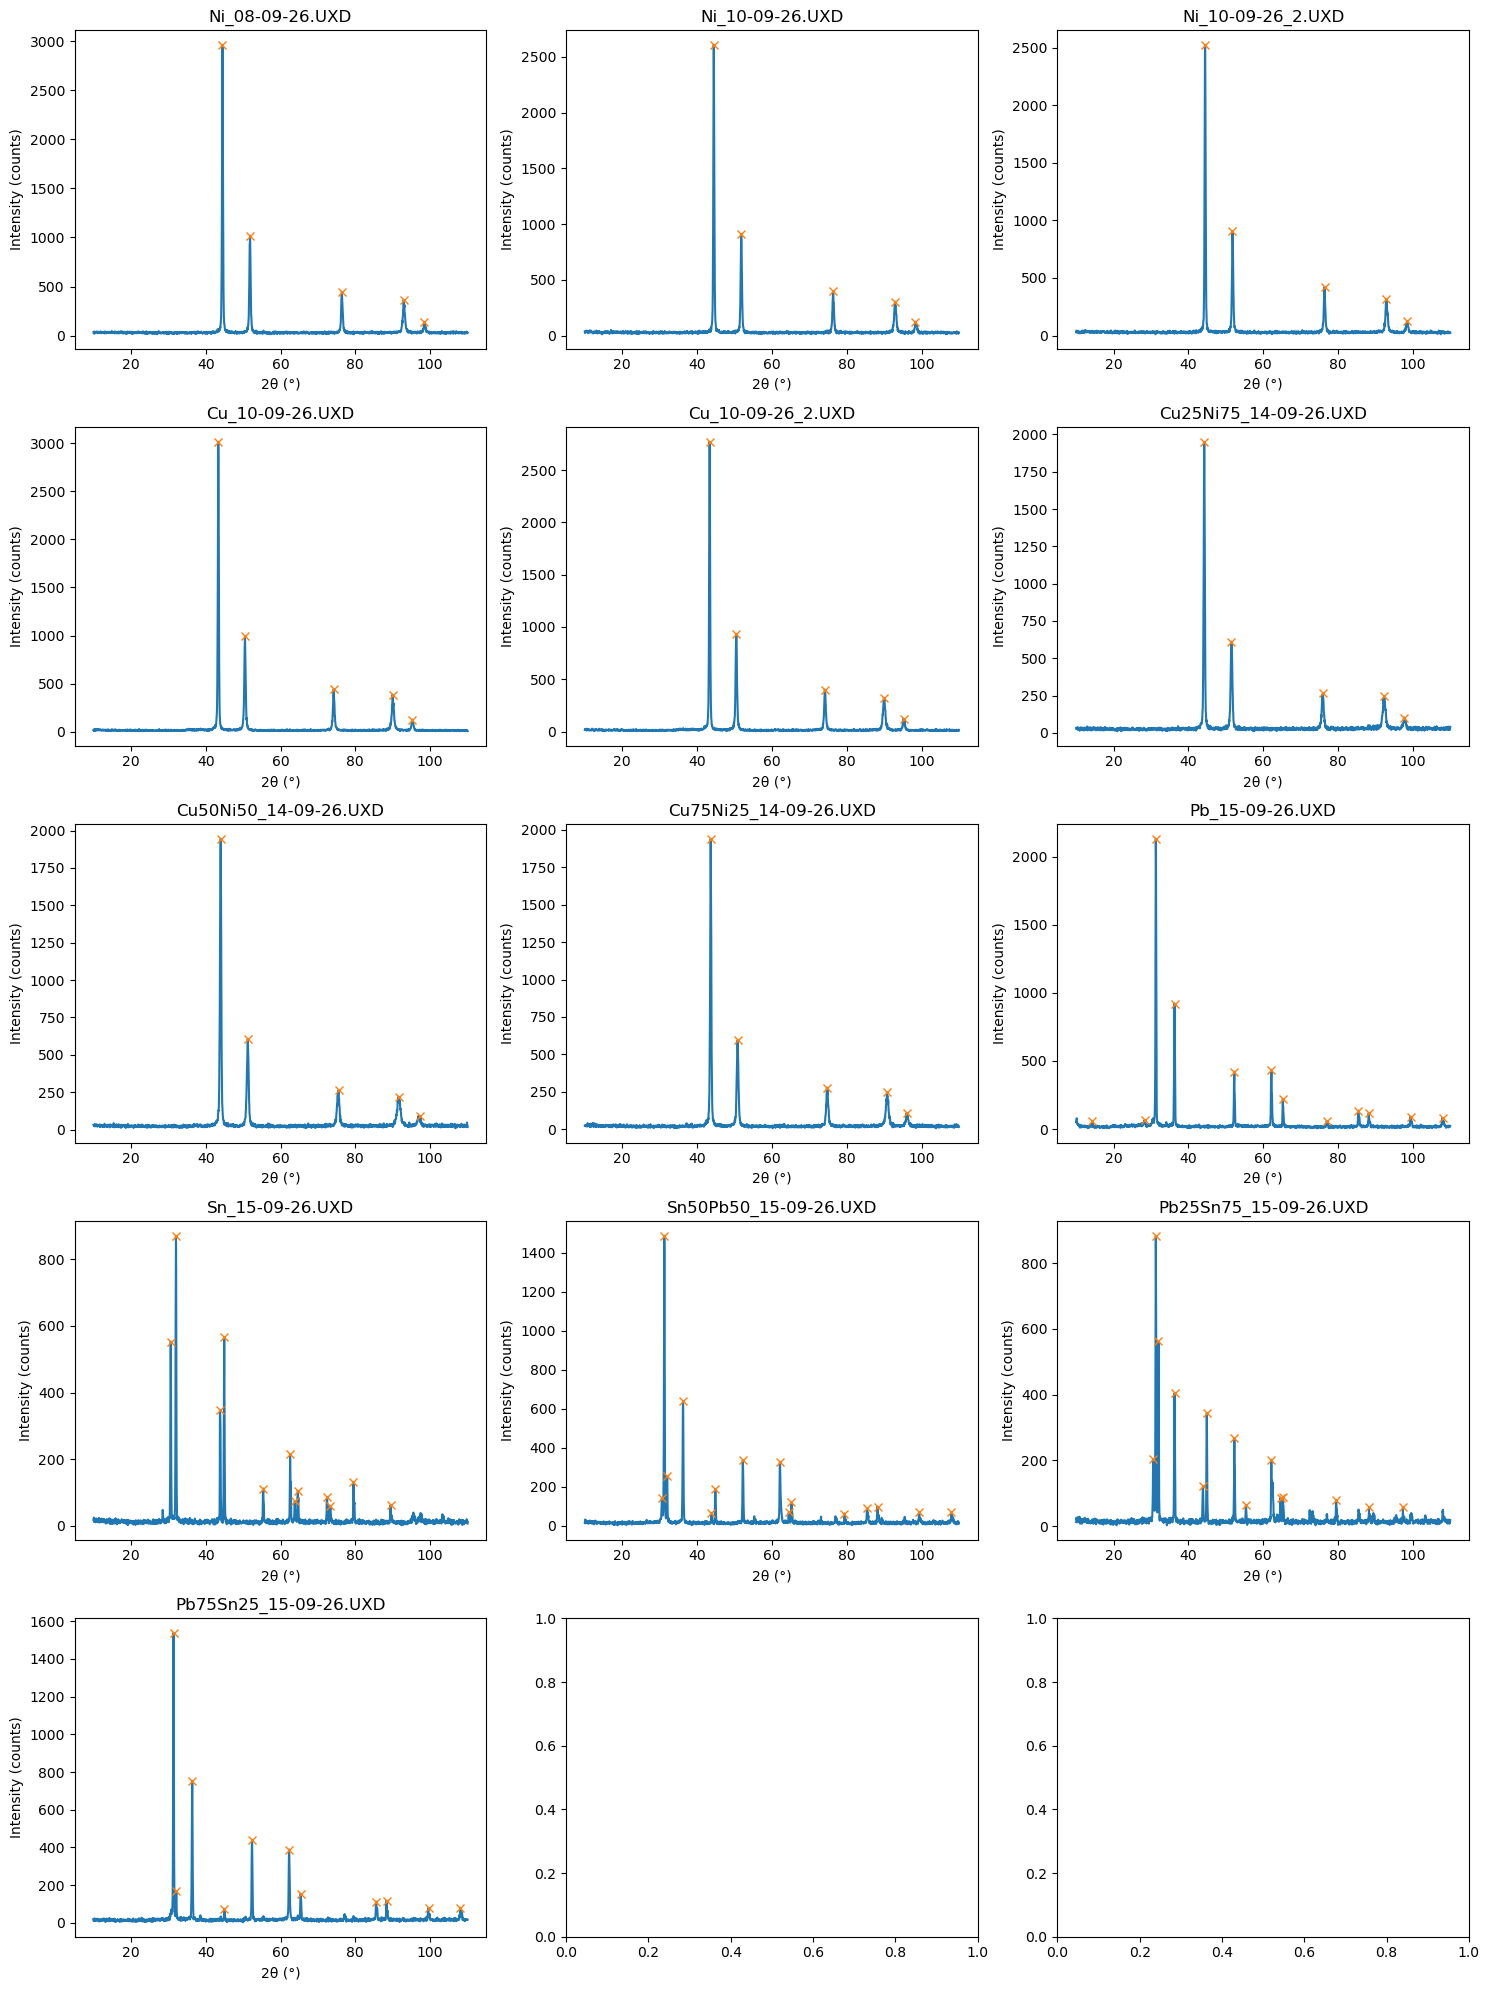

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# List of files
files = [
    "XRD_data/Ni_08-09-26.UXD",
    "XRD_data/Ni_10-09-26.UXD",
    "XRD_data/Ni_10-09-26_2.UXD",
    "XRD_data/Cu_10-09-26.UXD",
    "XRD_data/Cu_10-09-26_2.UXD",
    "XRD_data/Cu25Ni75_14-09-26.UXD",
    "XRD_data/Cu50Ni50_14-09-26.UXD",
    "XRD_data/Cu75Ni25_14-09-26.UXD",
    "XRD_data/Pb_15-09-26.UXD",
    "XRD_data/Sn_15-09-26.UXD",
    "XRD_data/Sn50Pb50_15-09-26.UXD",
    "XRD_data/Pb25Sn75_15-09-26.UXD",
    "XRD_data/Pb75Sn25_15-09-26.UXD"
]

fig, axes = plt.subplots(5, 3, figsize=(15, 20))

axes = axes.flatten()

peak_angles = {}
peak_intensities = {}
peak_d = {}

# Bragg's law
wavelength = 1.5406  # Angstrom, Cu K_alpha
n = 1

for i, file in enumerate(files):

    # Load data
    data = np.loadtxt(file)

    twotheta = data[:, 0]
    intensity = data[:, 1]

    # Find peaks
    peaks, _ = find_peaks(intensity, prominence=50)

    # Store peak angles and intensities
    name = file.split("/")[-1].replace(".UXD", "")
    peak_angles[name] = twotheta[peaks]
    peak_intensities[name] = intensity[peaks]

    theta = np.radians(twotheta[peaks] / 2)
    peak_d[name] = wavelength / (2 * np.sin(theta))

    # Print peaks
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print("2θ (°)       Intensity       d (Å)")
    print("----------------------------------------")

    for angle, I in zip(twotheta[peaks], intensity[peaks]):

        theta = np.radians(angle / 2    )
        d = wavelength / (2 * np.sin(theta))

        print(f"{angle:7.2f}       {I:8.0f}       {d:7.5f}")

    # Plot
    axes[i].plot(twotheta, intensity)

    # Labels
    axes[i].set_xlabel("2θ (°)")
    axes[i].set_ylabel("Intensity (counts)")
    axes[i].set_title(file.split("/")[-1])

    # Show peaks
    axes[i].plot(twotheta[peaks], intensity[peaks], "x")
    
# Make spacing nicer
plt.tight_layout()

plt.show()

In [12]:
for name in peak_d:

    d = peak_d[name]

    # Calculate 1/d^2
    Q = 1 / d**2

    # Normalize to the first peak
    ratio = Q / Q[0]

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Peak   d (Å)       1/d²        Ratio")
    print("-------------------------------------------")

    for i in range(len(d)):
        print(f"{i+1:4d}   {d[i]:8.5f}   {Q[i]:8.4f}   {ratio[i]:8.4f}")

    # Compare with common cubic series
    print("\nPossible cubic series:")

    # Simple cubic
    SC = np.array([1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12])

    # BCC: h+k+l even
    BCC = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])

    # FCC: h,k,l all odd or all even
    FCC = np.array([3, 4, 8, 11, 12, 16, 19, 20, 24, 27])

    # Normalize each series to its first value
    series = {
        "SC": SC / SC[0],
        "BCC": BCC / BCC[0],
        "FCC": FCC / FCC[0]
    }

    for crystal, values in series.items():

        # Only compare as many values as we have peaks
        n = min(len(ratio), len(values))

        error = np.mean((ratio[:n] - values[:n])**2)

        print(f"{crystal}: {values[:n]}   error = {error:.5f}")


Ni_08-09-26
Peak   d (Å)       1/d²        Ratio
-------------------------------------------
   1    2.03651     0.2411     1.0000
   2    1.76192     0.3221     1.3360
   3    1.24562     0.6445     2.6730
   4    1.06281     0.8853     3.6716
   5    1.01796     0.9650     4.0023

Possible cubic series:
SC: [1. 2. 3. 4. 5.]   error = 0.33020
BCC: [1. 2. 3. 4. 5.]   error = 0.33020
FCC: [1.         1.33333333 2.66666667 3.66666667 4.        ]   error = 0.00002

Ni_10-09-26
Peak   d (Å)       1/d²        Ratio
-------------------------------------------
   1    2.03651     0.2411     1.0000
   2    1.76350     0.3216     1.3336
   3    1.24562     0.6445     2.6730
   4    1.06237     0.8860     3.6747
   5    1.01796     0.9650     4.0023

Possible cubic series:
SC: [1. 2. 3. 4. 5.]   error = 0.33044
BCC: [1. 2. 3. 4. 5.]   error = 0.33044
FCC: [1.         1.33333333 2.66666667 3.66666667 4.        ]   error = 0.00002

Ni_10-09-26_2
Peak   d (Å)       1/d²        Ratio
--------------


Ni_08-09-26
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)
---------------------------------------------------------------
   1    44.4801   ±  0.0004         2872    2.03520
   2    51.8332   ±  0.0015          943    1.76245
   3    76.3915   ±  0.0039          386    1.24574
   4    92.9635   ±  0.0061          292    1.06226
   5    78.3384   ± 19.8663           33    1.21958

Ni_10-09-26
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)
---------------------------------------------------------------
   1    44.4820   ±  0.0004         2529    2.03512
   2    51.8336   ±  0.0015          838    1.76244
   3    76.3901   ±  0.0041          336    1.24575
   4    92.9670   ±  0.0064          257    1.06222
   5    18.9998   ± 212.4540           31    4.66719

Ni_10-09-26_2
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)
---------------------------------------------------------------
   1    44.4798   ±  0.0004         2469    2.03522
   2    51.830

C:\Users\micha\AppData\Local\Temp\ipykernel_556\3533719215.py:105: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(



Pb_15-09-26
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)
---------------------------------------------------------------
   1     8.0063   ±     inf          428   11.03399
   2    60.7934   ±     inf          877    1.52238
   3    31.3169   ±     inf         2110    2.85400
   4    36.2990   ±     inf          909    2.47289
   5    52.2838   ±     inf          367    1.74831
   6    62.2060   ±     inf          403    1.49116
   7    65.2918   ±     inf          176    1.42795
   8    61.0271   ±     inf         -859    1.51711
   9    85.5180   ±     inf          102    1.13460
  10    88.2626   ±     inf           70    1.10627
  11    99.4475   ±     inf           54    1.00965
  12   108.0224   ±     inf           51    0.95201

Sn_15-09-26
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)
---------------------------------------------------------------
   1    30.6448   ±  0.0009          543    2.91504
   2    32.0436   ±  0.0006          853    2.7909

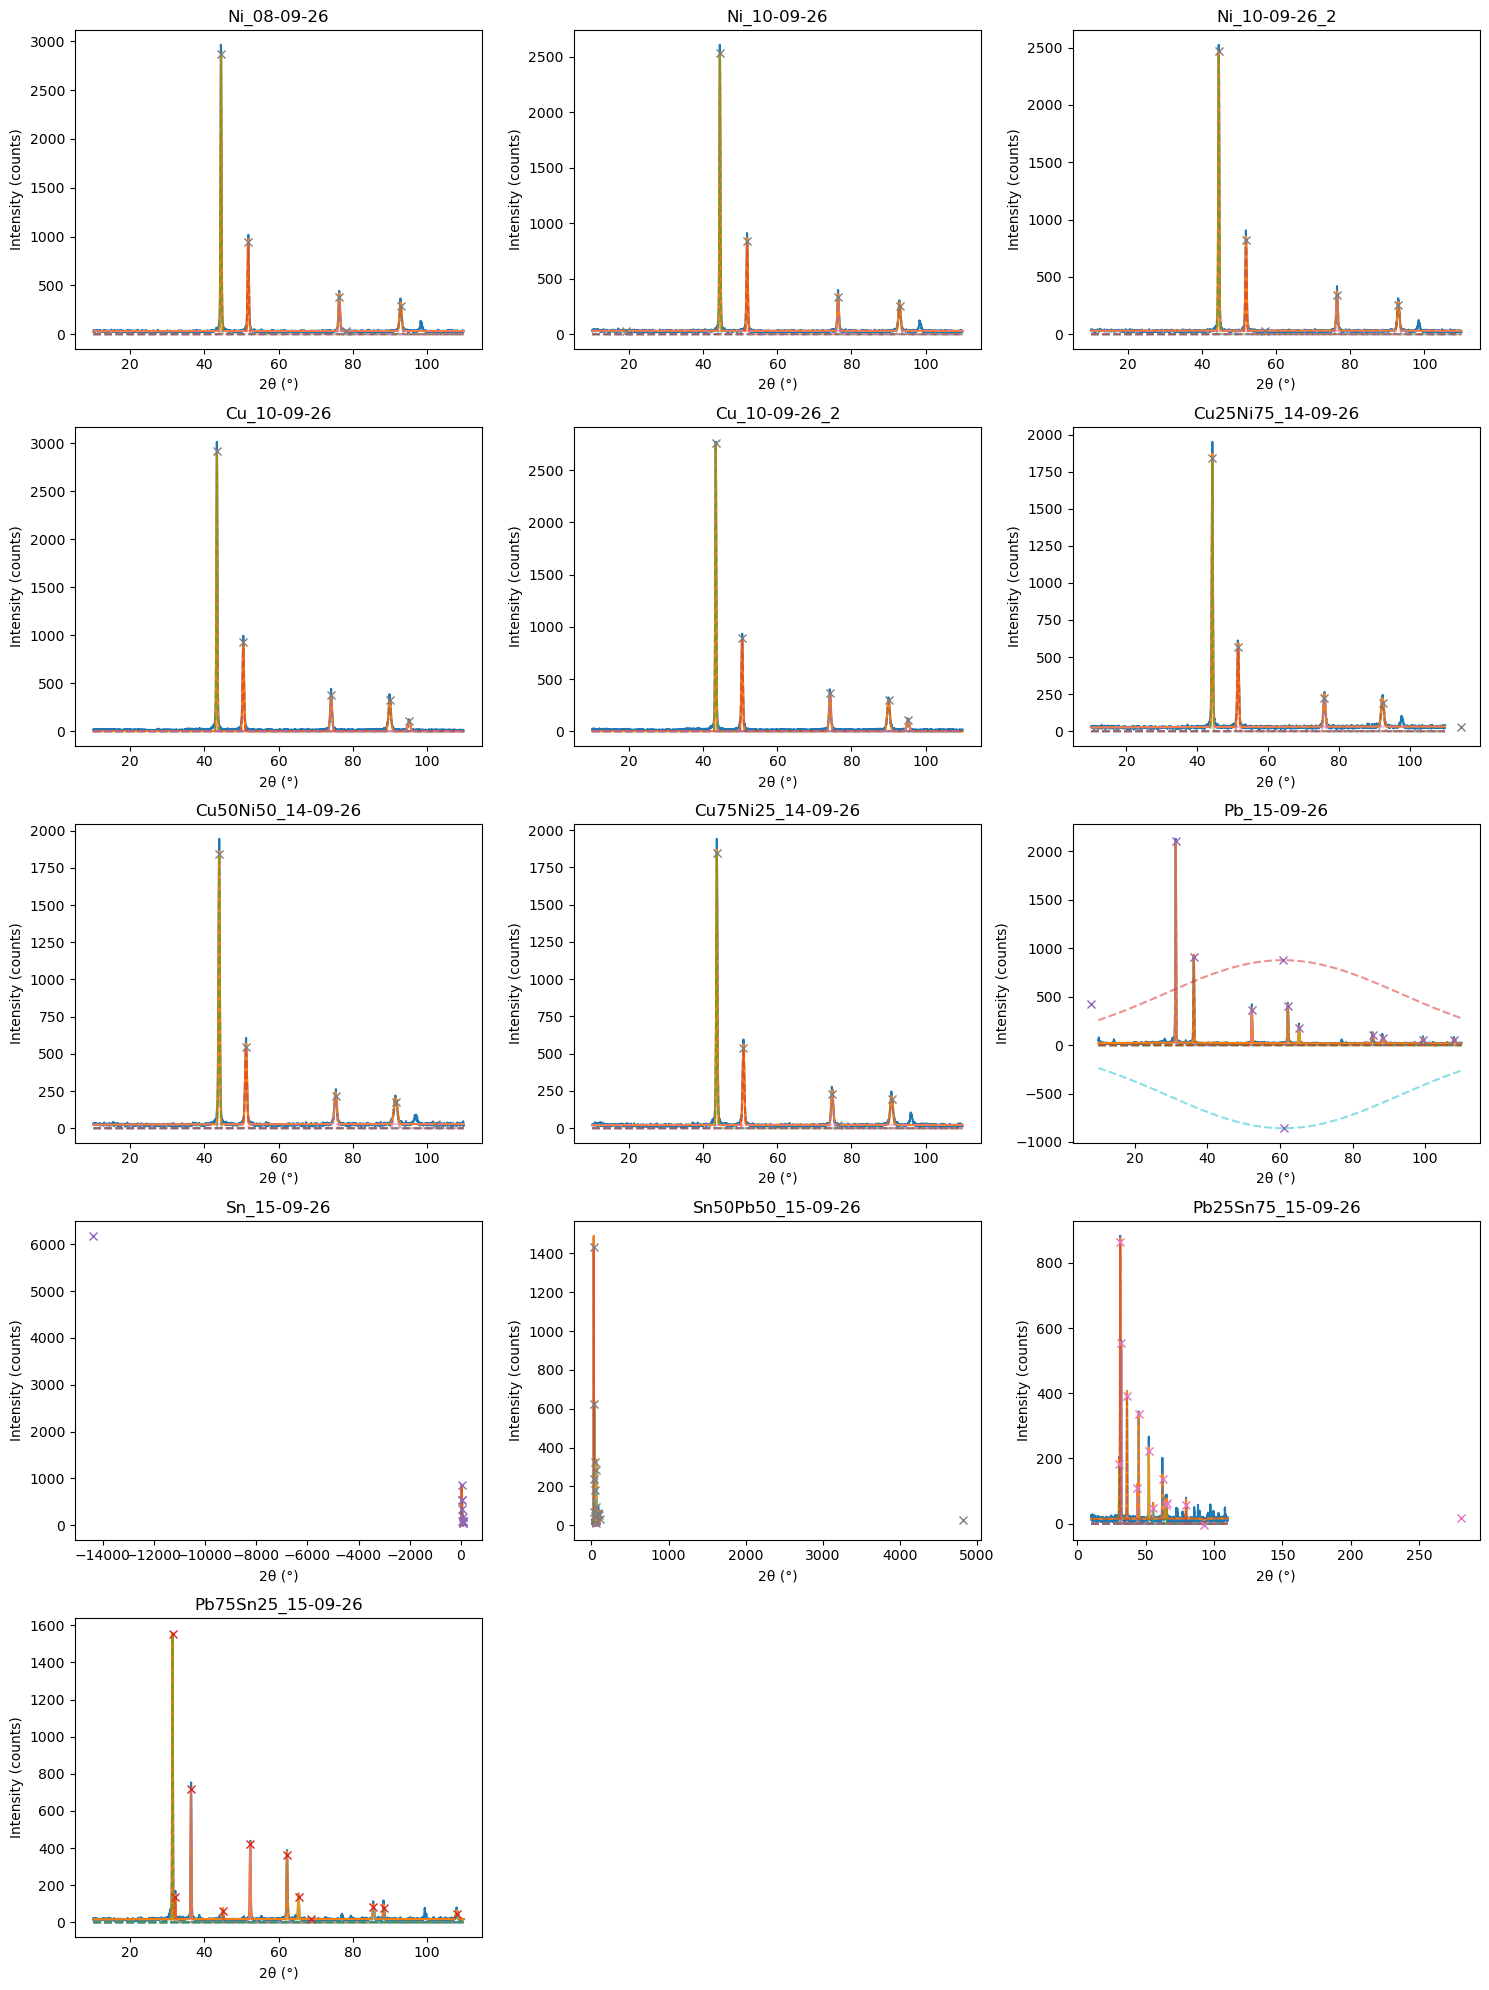

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# List of files
files = [
    "XRD_data/Ni_08-09-26.UXD",
    "XRD_data/Ni_10-09-26.UXD",
    "XRD_data/Ni_10-09-26_2.UXD",
    "XRD_data/Cu_10-09-26.UXD",
    "XRD_data/Cu_10-09-26_2.UXD",
    "XRD_data/Cu25Ni75_14-09-26.UXD",
    "XRD_data/Cu50Ni50_14-09-26.UXD",
    "XRD_data/Cu75Ni25_14-09-26.UXD",
    "XRD_data/Pb_15-09-26.UXD",
    "XRD_data/Sn_15-09-26.UXD",
    "XRD_data/Sn50Pb50_15-09-26.UXD",
    "XRD_data/Pb25Sn75_15-09-26.UXD",
    "XRD_data/Pb75Sn25_15-09-26.UXD"
]

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.flatten()

peak_angles = {}
peak_intensities = {}
peak_d = {}
peak_uncertainties = {}


# ---------------------------------------------------------
# Gaussian functions
# ---------------------------------------------------------

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))


def gaussian_sum(x, *params):

    y = np.zeros_like(x)

    # Every peak has 3 parameters:
    # amplitude, center, width
    for i in range(0, len(params), 3):

        A = params[i]
        mu = params[i + 1]
        sigma = params[i + 2]

        y += gaussian(x, A, mu, sigma)

    return y


# Bragg's law
wavelength = 1.5406  # Angstrom, Cu K_alpha
n = 1


for i, file in enumerate(files):

    # -----------------------------------------------------
    # Load data
    # -----------------------------------------------------

    data = np.loadtxt(file)

    twotheta = data[:, 0]
    intensity = data[:, 1]


    # -----------------------------------------------------
    # Step 1: Find rough peak positions
    # -----------------------------------------------------

    peaks, _ = find_peaks(intensity, prominence=50)

    rough_positions = twotheta[peaks]
    rough_heights = intensity[peaks]


    # -----------------------------------------------------
    # Step 2: Initial guesses for Gaussian fit
    # -----------------------------------------------------

    initial_guess = []

    for position, height in zip(rough_positions, rough_heights):

        initial_guess.extend([
            height,      # amplitude
            position,    # center
            0.15         # sigma (degrees)
        ])


    # -----------------------------------------------------
    # Fit sum of Gaussians
    # -----------------------------------------------------

    try:

        popt, pcov = curve_fit(
            gaussian_sum,
            twotheta,
            intensity,
            p0=initial_guess,
            maxfev=50000
        )

        # Parameter uncertainties
        perr = np.sqrt(np.diag(pcov))

        fit_success = True

    except RuntimeError:

        print("Fit failed for:", file)

        fit_success = False


    # -----------------------------------------------------
    # Store fitted peak information
    # -----------------------------------------------------

    name = file.split("/")[-1].replace(".UXD", "")

    if fit_success:

        fitted_angles = []
        fitted_intensities = []
        fitted_d = []
        fitted_uncertainties = []

        for j in range(len(rough_positions)):

            A = popt[3*j]
            mu = popt[3*j + 1]
            sigma = popt[3*j + 2]

            mu_error = perr[3*j + 1]

            # Bragg's law
            theta = np.radians(mu / 2)
            d = wavelength / (2 * np.sin(theta))

            fitted_angles.append(mu)
            fitted_intensities.append(A)
            fitted_d.append(d)
            fitted_uncertainties.append(mu_error)


        peak_angles[name] = np.array(fitted_angles)
        peak_intensities[name] = np.array(fitted_intensities)
        peak_d[name] = np.array(fitted_d)
        peak_uncertainties[name] = np.array(fitted_uncertainties)


        # -------------------------------------------------
        # Print results
        # -------------------------------------------------

        print("\n" + "=" * 75)
        print(name)
        print("=" * 75)

        print("Peak   2θ (°)       ± uncertainty     Intensity       d (Å)")
        print("---------------------------------------------------------------")

        for j in range(len(fitted_angles)):

            print(
                f"{j+1:4d}   "
                f"{fitted_angles[j]:8.4f}   "
                f"± {fitted_uncertainties[j]:7.4f}   "
                f"{fitted_intensities[j]:10.0f}   "
                f"{fitted_d[j]:8.5f}"
            )


        # -------------------------------------------------
        # Plot original data
        # -------------------------------------------------

        axes[i].plot(
            twotheta,
            intensity,
            label="Data"
        )


        # Plot total Gaussian fit
        fit = gaussian_sum(twotheta, *popt)

        axes[i].plot(
            twotheta,
            fit,
            label="Gaussian fit"
        )


        # Plot individual Gaussians
        for j in range(len(rough_positions)):

            A = popt[3*j]
            mu = popt[3*j + 1]
            sigma = popt[3*j + 2]

            component = gaussian(
                twotheta,
                A,
                mu,
                sigma
            )

            axes[i].plot(
                twotheta,
                component,
                "--",
                alpha=0.5
            )


        # Mark fitted centers
        axes[i].plot(
            fitted_angles,
            fitted_intensities,
            "x"
        )


    else:

        # If fit fails, just plot original data
        axes[i].plot(twotheta, intensity)


    # Labels
    axes[i].set_xlabel("2θ (°)")
    axes[i].set_ylabel("Intensity (counts)")
    axes[i].set_title(name)


# Turn off unused subplot
for i in range(len(files), len(axes)):
    axes[i].axis("off")


plt.tight_layout()
plt.show()